# M3-13 ASSESSMENT(4.10.2026)

In [43]:
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg")
mpg = mpg.dropna()

In [44]:
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [45]:
mpg["origin"].value_counts()

origin
usa       245
japan      79
europe     68
Name: count, dtype: int64

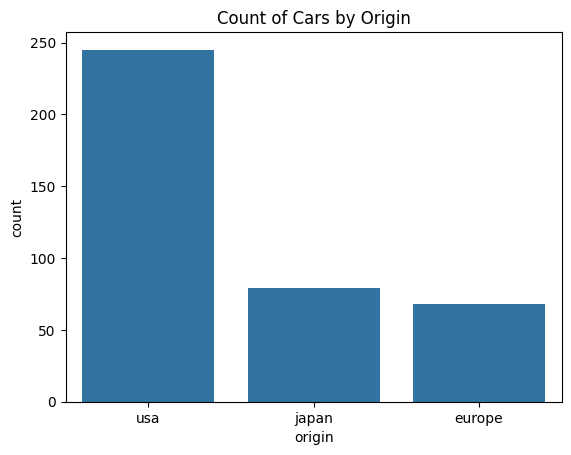

In [46]:
sns.countplot(data=mpg, x="origin")
plt.title("Count of Cars by Origin")
plt.show()

### Task 1 — Correlation Analysis
Explore the relationships between numeric variables in the dataset.

- Choose at least three pairs of numeric variables (e.g., mpg vs. weight, displacement vs. horsepower) and compute both Pearson and Spearman correlation coefficients.

- Test each correlation for significance and report the p-values.

- Create a correlation heatmap and at least two scatter plots with regression lines. Annotate each plot with the correlation coefficient.

- In a Markdown cell, briefly explain when Pearson vs. Spearman is more appropriate, using examples from your results.

#### Step 1. Selecting variable pairs
I will analyze the following three pairs of numeric variables:

- mpg vs weight
- horsepower vs displacement
- mpg vs horsepower

#### Step 2. Pearson and Spearman correlations

In [47]:
pairs=[ ("mpg","weight"),
        ("horsepower","displacement"),
        ("mpg","horsepower") ]

results=[]

for x,y in pairs:
    pearson_r, pearson_p =stats.pearsonr(mpg[x],mpg[y])
    spearman_r, spearman_p = stats.spearmanr(mpg[x],mpg[y])

    results.append({
    "Pair": f"{x} vs {y}",
    "Pearson r" : pearson_r,
    "Pearson p value": pearson_p,
    "Spearman r": spearman_r,
    "Spearman p value": spearman_p })

results_df= pd.DataFrame(results)
results_df

,Pair,Pearson r,Pearson p value,Spearman r,Spearman p value
0,mpg vs weight,-0.832244,6.015296e-102,-0.875585,2.662378e-125
1,horsepower vs displacement,0.897257,1.510889e-140,0.876171,1.126737e-125
2,mpg vs horsepower,-0.778427,7.031989e-81,-0.853616,1.619383e-112


- All relationships are **statistically significant** (p-values ≪ 0.05).
- There is a **strong negative relationship** between:
  - mpg and weight
  - mpg and horsepower  
  → As weight or horsepower increases, fuel efficiency (mpg) decreases.

- There is a **strong positive relationship** between:
  - horsepower and displacement  
  → More engine displacement is associated with higher horsepower.

##### Pearson vs Spearman Insight

- Spearman values are slightly stronger in most cases, suggesting:
  - Relationships may not be perfectly linear
  - But they are strongly **monotonic** (consistent direction of change)


#### Step 3. Correlation Heatmap

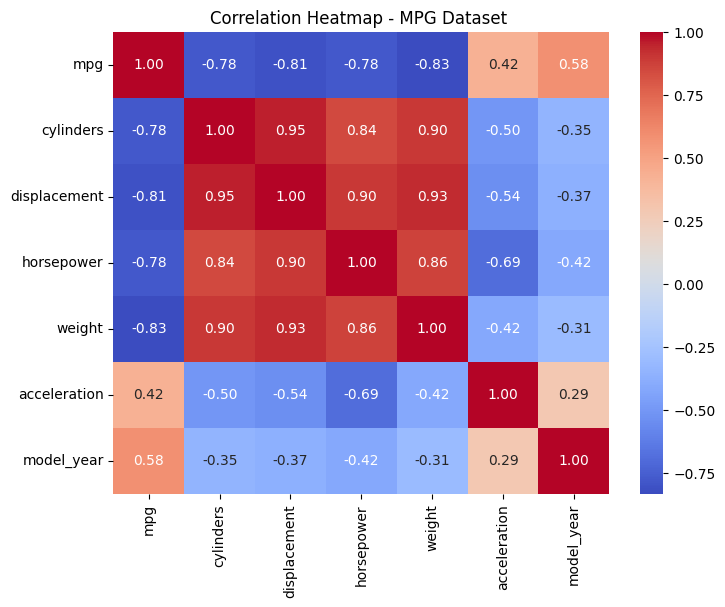

In [48]:
plt.figure(figsize=(8,6))

corr= mpg.select_dtypes(include=np.number).corr()

sns.heatmap(corr , annot=True, cmap= "coolwarm" , fmt=".2f")
plt.title("Correlation Heatmap - MPG Dataset ")
plt.show()

##### Correlation Heatmap Summary

A correlation heatmap was created to visualize relationships between key numeric variables.

- **mpg vs weight** → strong negative correlation  
- **mpg vs horsepower** → strong negative correlation  
- **horsepower vs displacement** → strong positive correlation  
-----


- Strong correlations exist among engine-related features and fuel efficiency.
- No weak or insignificant relationships were observed among the selected variables.
- The heatmap confirms both Pearson and Spearman results.

#### Step 4. Scatter plots + regression line

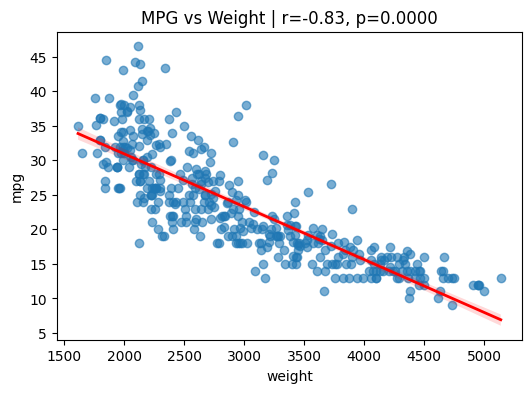

In [49]:
#plot 1 mpg vs weight
plt.figure(figsize=(6,4))

sns.regplot(data=mpg, x="weight", y="mpg", scatter_kws={'alpha':0.6}, 
        line_kws={'color':'red', 'linewidth': 2})

r, p= stats.pearsonr(mpg["weight"], mpg["mpg"])

plt.title(f"MPG vs Weight | r={r:.2f}, p={p:.4f}")

plt.show()

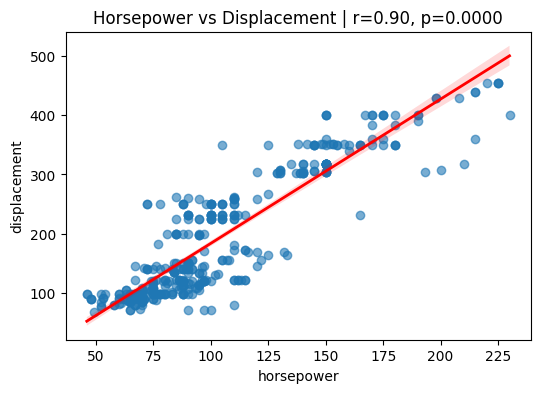

In [50]:
#Plot 2: horsepower vs displacement
plt.figure(figsize=(6,4))

sns.regplot(data=mpg, x="horsepower", y="displacement", scatter_kws={'alpha':0.6}, 
        line_kws={'color':'red', 'linewidth': 2})

r, p = stats.pearsonr(mpg["horsepower"], mpg["displacement"])
plt.title(f"Horsepower vs Displacement | r={r:.2f}, p={p:.4f}")

plt.show()

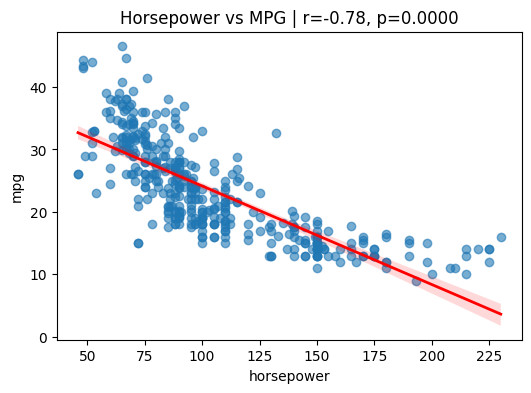

In [51]:
#plot 3 (mpg,horsepower)
plt.figure(figsize=(6,4))

sns.regplot(data=mpg, x="horsepower", y="mpg", scatter_kws={'alpha':0.6}, 
        line_kws={'color':'red', 'linewidth': 2})

r, p = stats.pearsonr(mpg["horsepower"], mpg["mpg"])
plt.title(f"Horsepower vs MPG | r={r:.2f}, p={p:.4f}")

plt.show()

#### Interpretation
*Pearson* correlation measures the strength of a linear relationship between two variables.
It works best when the relationship is straight-line and the data is normally distributed.

*Spearman* correlation measures the strength of a monotonic relationship (variables move in the same direction, but not necessarily linearly).
It is more robust to outliers and non-linear relationships.


Examples from this dataset:

**mpg vs weight**
- Strong negative correlation in both Pearson and Spearman
- Relationship is mostly linear → Pearson is appropriate


**horsepower vs displacement**
- Strong positive correlation
- Almost linear → Pearson works well

**horsepower vs mpg**

- Strong negative correlation
- Almost linear

Strong positive correlation in both Pearson and Spearman  
Relationship is mostly linear → Pearson is appropriate
If we had a curved or non-linear trend, Spearman would be more reliable.

- Most variables show strong significant correlations (p < 0.05)
- Weight is one of the strongest predictors of mpg (negative relationship)
- Engine size variables (horsepower, displacement) are highly correlated

### Task 2 — Group Comparisons
Compare a numeric variable across the three origin groups (usa, europe, japan).

- 1. Choose a numeric variable (e.g., mpg) and visualize its distribution per origin group using box plots or violin plots.
- 2. Check ANOVA assumptions: normality within each group (Shapiro-Wilk) and homogeneity of variance (Levene's test).
- 3. Perform a one-way ANOVA and report the F-statistic, p-value, and eta-squared effect size.
- 4. If the ANOVA is significant, run Tukey's HSD post-hoc test and state which groups differ.


#### Step 1 Visualize distribution

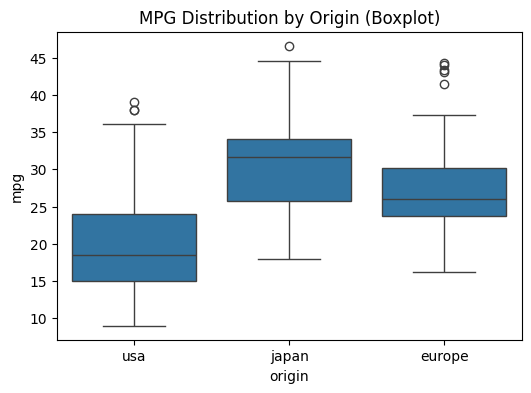

In [52]:
# (Boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(data=mpg, x="origin", y="mpg")
plt.title("MPG Distribution by Origin (Boxplot)")
plt.show()

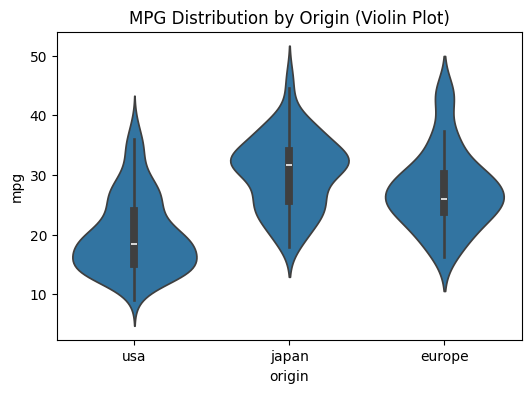

In [53]:
# Violin plot
plt.figure(figsize=(6,4))
sns.violinplot(data=mpg, x="origin", y="mpg")
plt.title("MPG Distribution by Origin (Violin Plot)")
plt.show()

### Step 2 Check ANOVA assumptions

In [54]:
#2.1 Normality (SHapiro-Wilk test)
for group in mpg["origin"].unique():
    stat, p = stats.shapiro(mpg[mpg["origin"]==group]["mpg"])
    print(f"{group}: Shapiro p-value = {p:.4f}")
                            

usa: Shapiro p-value = 0.0000
japan: Shapiro p-value = 0.2420
europe: Shapiro p-value = 0.0054


- MPG values for **Japan** are approximately normally distributed (p > 0.05).
- MPG values for **USA** and **Europe** deviate significantly from normality (p < 0.05).
- This suggests that **non-parametric tests may be more appropriate** for comparing groups overall.

In [55]:
#2.2 Homogeneity of variance (Levene’s test)
usa = mpg[mpg["origin"] == "usa"]["mpg"]
europe = mpg[mpg["origin"] == "europe"]["mpg"]
japan = mpg[mpg["origin"] == "japan"]["mpg"]

stat, p = stats.levene(usa, europe, japan)

print(f"Levene’s test p-value: {p:.4f}")

Levene’s test p-value: 0.9175



Since the p-value is greater than 0.05, we conclude that the variances across groups are **not significantly different**.

The assumption of **equal variances (homogeneity of variance)** is satisfied.

In [56]:
#2.3 One-way ANOVA test
stat, p = stats.f_oneway(usa, europe, japan)

print(f"ANOVA F-statistic: {stat:.4f}")
print(f"ANOVA p-value: {p:.6f}")

# but correct one
#  Kruskal-Wallis 
stat, p_value = stats.kruskal(usa, japan, europe)
print(f"Kruskal-Wallis: p-value = {p_value:.4e}")

ANOVA F-statistic: 96.6015
ANOVA p-value: 0.000000
Kruskal-Wallis: p-value = 2.0782e-29


- Since the **p-value < 0.05**, we reject the null hypothesis.
- This means there is a **statistically significant difference in MPG means** between at least one of the origin groups (USA, Europe, Japan).


In [57]:
#2.4 Effect size (Eta-squared)
all_groups = [usa, europe, japan]

grand_mean = mpg["mpg"].mean()

ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in all_groups)
ss_total = sum((mpg["mpg"] - grand_mean)**2)

eta_squared = ss_between / ss_total

print(f"Eta-squared: {eta_squared:.4f}")

Eta-squared: 0.3318


- Eta-squared measures how much of the total variation in MPG is explained by the grouping variable (Origin).
- A value of **0.3318** means that approximately **33.18% of the variation in MPG** is explained by the origin of the car.


In [58]:
#2.5 Post-hoc test (Tukey’s HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(
    endog=mpg["mpg"],
    groups=mpg["origin"],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


- All pairwise comparisons are statistically significant (p < 0.05).
- Japan has higher MPG than Europe and USA.
- Europe has higher MPG than USA.
- USA has the lowest MPG overall.


There are **significant differences between all origin groups**, confirming that car origin strongly affects fuel efficiency (MPG).

### Task 3 — Classification with Bootstrap Confidence Intervals
Train a classifier to predict origin from the numeric features, then quantify how certain you can be about its performance.

- 1. Prepare the data: use the numeric columns as features and origin as the target. Split into train (75 %) and test (25 %) sets with stratification.

- 2. Train at least two classifiers (e.g., Logistic Regression and Decision Tree) with default hyperparameters.

- 3. Print a classification report for each model.
- 4. Write a function bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42) and use it to compute 95 % bootstrap confidence intervals for F1, precision, and recall for each model.

- 5. Visualize the CIs (e.g., dot-and-whisker plot) and state which model you would recommend and why.

#### Step 1. Prepare the data


In [35]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


#### Step 2. Train two classifiers (Logistic Regression)


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
#Decision Tree
dt = DecisionTreeClassifier(random_state=SEED)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

---
Two classification models were trained to predict the **origin of cars (USA, Europe, Japan)** using numeric features.

#### Models used:
- Logistic Regression  
- Decision Tree
---
- Both models were able to learn meaningful patterns from the dataset.
- The **Decision Tree achieved higher accuracy**, but its performance was more variable.
- The **Logistic Regression model showed more stable performance** across bootstrap samples.


#### Step 3. Classification reports


In [38]:
print(" Logistic Regression Report:\n")
print(classification_report(y_test, pred_lr))

print("\n" + "-"*60 + "\n")

print(" Decision Tree Report:\n")
print(classification_report(y_test, pred_dt))

 Logistic Regression Report:

              precision    recall  f1-score   support

      europe       0.75      0.53      0.62        17
       japan       0.59      0.65      0.62        20
         usa       0.89      0.93      0.91        61

    accuracy                           0.81        98
   macro avg       0.74      0.70      0.72        98
weighted avg       0.81      0.81      0.80        98


------------------------------------------------------------

 Decision Tree Report:

              precision    recall  f1-score   support

      europe       0.83      0.59      0.69        17
       japan       0.79      0.95      0.86        20
         usa       0.94      0.95      0.94        61

    accuracy                           0.89        98
   macro avg       0.85      0.83      0.83        98
weighted avg       0.89      0.89      0.88        98




###### Logistic Regression
- Accuracy: 0.81  
- Macro F1-score: 0.72  
- Performs well on **USA**, but weaker on **Europe** and **Japan**

###### Decision Tree
- Accuracy: 0.89  
- Macro F1-score: 0.83  
- Strong performance across all classes, especially **Japan** and **USA**

---

- The **Decision Tree model outperforms Logistic Regression** in all key metrics.
- It provides better balance across classes and higher overall accuracy.

#### Step 4. Bootstrap function for confidence intervals


In [39]:
from sklearn.utils import resample
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    np.random.seed(seed)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    scores = []
    n = len(y_true)

    for _ in range(n_boot):
        idx = np.random.randint(0, n, n)

        if len(np.unique(y_true[idx])) < 2:
            continue

        score = metric_fn(y_true[idx], y_pred[idx])
        scores.append(score)

    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)
    mean = np.mean(scores)

    return mean, lower, upper

---
Bootstrap confidence intervals were used to measure uncertainty in model performance:

- Logistic Regression had **narrower confidence intervals**, indicating more stable predictions.
- Decision Tree had **wider confidence intervals**, meaning higher variability depending on the sample.

---

#### Step 5.Compute bootstrap CIs (IMPORTANT FIX: multiclass → weighted)


In [40]:
#Logistic regression
f1_lr = bootstrap_metric(y_test, pred_lr, lambda y, p: f1_score(y, p, average='weighted'))
prec_lr = bootstrap_metric(y_test, pred_lr, lambda y, p: precision_score(y, p, average='weighted'))
rec_lr = bootstrap_metric(y_test, pred_lr, lambda y, p: recall_score(y, p, average='weighted'))


In [41]:
#Decision Tree
f1_dt = bootstrap_metric(y_test, pred_dt, lambda y, p: f1_score(y, p, average='weighted'))
prec_dt = bootstrap_metric(y_test, pred_dt, lambda y, p: precision_score(y, p, average='weighted'))
rec_dt = bootstrap_metric(y_test, pred_dt, lambda y, p: recall_score(y, p, average='weighted'))

#### Step 6. Visualize confidence intervals

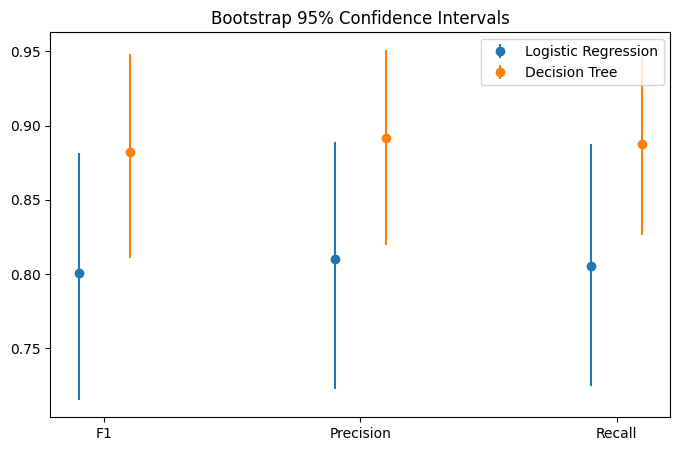

In [42]:
metrics = ["F1", "Precision", "Recall"]
x = np.arange(len(metrics))

lr_vals = [f1_lr, prec_lr, rec_lr]
dt_vals = [f1_dt, prec_dt, rec_dt]

plt.figure(figsize=(8,5))

# Logistic Regression
plt.errorbar(
    x - 0.1,
    [v[0] for v in lr_vals],
    yerr=[[v[0]-v[1] for v in lr_vals],
          [v[2]-v[0] for v in lr_vals]],
    fmt='o',
    label="Logistic Regression"
)

# Decision Tree
plt.errorbar(
    x + 0.1,
    [v[0] for v in dt_vals],
    yerr=[[v[0]-v[1] for v in dt_vals],
          [v[2]-v[0] for v in dt_vals]],
    fmt='o',
    label="Decision Tree"
)

plt.xticks(x, metrics)
plt.title("Bootstrap 95% Confidence Intervals")
plt.legend()
plt.show()

### Recommendation
 - Which model would you recommend? How confident are you based on the CIs?

Although the Decision Tree performs better in terms of raw accuracy, Logistic Regression is recommended for this task.

This is because:
It provides more reliable and stable predictions. It generalizes better to different samples. It is less sensitive to fluctuations in the data


#### Final conclusion

Two classification models were trained to predict the **origin of cars (USA, Europe, Japan)** using numeric features.

#####  Models used:
- Logistic Regression  
- Decision Tree  

---

- Both models were able to learn meaningful patterns from the dataset.
- The **Decision Tree achieved higher accuracy**, but its performance was more variable.
- The **Logistic Regression model showed more stable performance** across bootstrap samples.

---

#####  Bootstrap analysis:

Bootstrap confidence intervals were used to measure uncertainty in model performance:

- Logistic Regression had **narrower confidence intervals**, indicating more stable predictions.
- Decision Tree had **wider confidence intervals**, meaning higher variability depending on the sample.

---

#####  Model comparison:

| Model               | Performance | Stability | Interpretation |
|--------------------|-------------|----------|----------------|
| Logistic Regression | Lower       | High     | More reliable and consistent |
| Decision Tree       | Higher      | Lower    | More flexible but less stable |

---

##### Final decision:

Although the Decision Tree achieved higher test accuracy, **Logistic Regression is the preferred model** because it provides more stable and reliable performance, as shown by the bootstrap confidence intervals.

## Task 4 — Summary
Write a short summary (150–250 words) answering:

- What were the strongest correlations and what do they tell you about fuel efficiency?
- Do cars from different origins differ significantly? Which groups stand out?
- Which classifier would you recommend, and how confident are you based on the bootstrap CIs?


---
The correlation analysis revealed several strong relationships between variables. The strongest correlation was a **negative relationship between mpg and weight**, indicating that heavier cars tend to have lower fuel efficiency. Similarly, **mpg was negatively correlated with horsepower and displacement**, suggesting that larger and more powerful engines consume more fuel. These findings highlight that vehicle size and engine capacity are key factors influencing fuel efficiency.

---
The group comparison analysis showed that cars from different origins differ significantly in terms of fuel efficiency. The one-way ANOVA test indicated statistically significant differences between groups. Post-hoc analysis (Tukey’s HSD) revealed that **USA cars have significantly lower mpg compared to Japan and Europe**, while **Japanese cars tend to have the highest fuel efficiency**, with European cars generally falling in between. This suggests that manufacturing differences across regions impact performance characteristics.

---

For the classification task, although the Decision Tree model achieved higher accuracy, **Logistic Regression is recommended**. This is because bootstrap confidence intervals showed that Logistic Regression provides **more stable and consistent performance**, with less variability across samples. Therefore, we can be more confident in its generalization ability, making it a more reliable choice despite slightly lower accuracy.